# Fashion-MNIST Vanilla CNN Baseline



In [1]:
# !pip install torch
# !pip install torchvision
# !pip install matplotlib

In [2]:
import warnings

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

warnings.filterwarnings("ignore")

# Data Loading

[data] Fashion-MNIST

- 28×28 grayscale 의류 이미지, 클래스 10개
- Train 60,000 / Test 10,000
- MNIST와 이미지 크기는 같고, 분류 난이도는 더 높음

In [3]:
CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

In [4]:
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(
            (0.5,),  # 평균 0.5
            (0.5,),  # 표준편차 0.5
        ),
    ]
)

In [5]:
train_set = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_set = torchvision.datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

In [6]:
# train_set 중 일부를 validation set으로 분리 (train 90% / valid 10%)
valid_ratio = 0.1
train_size = int(len(train_set) * (1 - valid_ratio))
valid_size = len(train_set) - train_size

train_subset, valid_subset = torch.utils.data.random_split(
    train_set,
    [train_size, valid_size],
    generator=torch.Generator().manual_seed(42),
)

In [7]:
print(f"train_set size: {len(train_subset)}")
print(f"valid_set size: {len(valid_subset)}")
print(f"test_set size: {len(test_set)}")

train_set size: 54000
valid_set size: 6000
test_set size: 10000


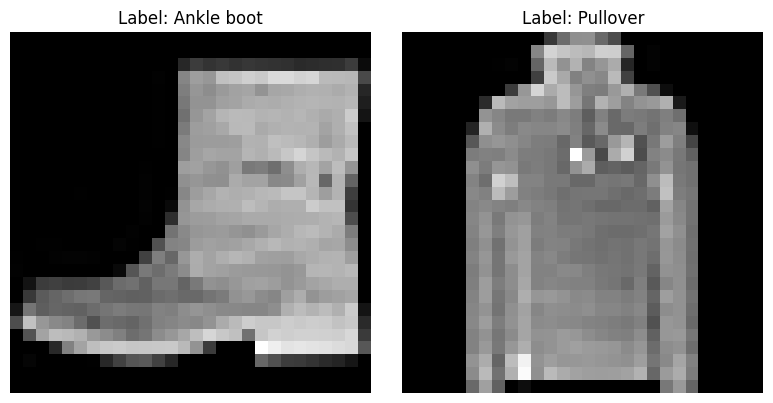

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

for i in range(2):
    image, label = train_subset[i]
    axes[i].imshow(image.squeeze(), cmap="gray")

    axes[i].set_title(f"Label: {CLASS_NAMES[label]}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

# CNN 반복 실험 기록

이 노트북은 **Base에서 시작해 한 번에 하나의 조건만 변경**하며 모델을 점진적으로 개선합니다.

각 실험은 `변경사항 → 가설 → 실험실행 → 결과 → 해석 → 시각화` 순서로 완결합니다. 다음 실험은 미리 정하지 않고, 직전 실험의 결과와 해석을 확인한 뒤 설계합니다.

## 공통 실험 원칙

- 데이터 분할과 random seed를 고정해 비교 조건을 맞춥니다.
- 한 실험에서는 하나의 요인만 변경합니다.
- 모델 선택과 실험 해석에는 validation 결과를 사용합니다.
- test set은 반복 실험 중 확인하지 않고, 최종 모델이 결정된 후 한 번만 평가합니다.
- 변경으로 성능이 개선되면 해당 설정을 다음 기준 모델로 채택하고, 개선되지 않으면 이전 최고 설정으로 돌아갑니다.

## 공통 함수

아래 코드는 Base와 이후 모든 실험에서 공통으로 사용합니다.

| 구성 | 역할 |
|---|---|
| `set_seed()` | 실험마다 난수 조건을 동일하게 설정 |
| `make_loaders()` | 기존 데이터 분할로 DataLoader 생성 |
| `FashionCNN` | 공통 CNN 모델 정의 |
| `evaluate()` | 평가 모드에서 train/validation/test loss와 accuracy 계산 |
| `run_experiment()` | 학습, checkpoint 복원, 동일 조건 재평가 수행 |
| `plot_comparison()` | epoch별 학습 곡선 비교 |
| `plot_best_valid_accuracy()` | 최고 validation accuracy 비교 |

In [9]:
import copy
import random


# 모델 두 개를 공정하게 비교하려면 난수 조건도 같아야 합니다.
def set_seed(seed=42):
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)


# 사용 가능한 가속 장치가 있으면 자동으로 선택합니다.
def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


# 이후 실험에서도 동일한 batch_size와 데이터 분할을 사용합니다.
def make_loaders(batch_size=256):
    # 기존에 생성한 train_subset, valid_subset, test_set을 그대로 사용합니다.
    return (
        torch.utils.data.DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=0),
        torch.utils.data.DataLoader(valid_subset, batch_size=batch_size, shuffle=False, num_workers=0),
        torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=0),
    )


def make_activation(activation_name):
    """문자열 설정값에 맞는 새로운 Activation 객체를 생성합니다."""
    if activation_name == "ReLU":
        return nn.ReLU()
    if activation_name == "LeakyReLU":
        return nn.LeakyReLU(negative_slope=0.1)
    if activation_name == "GELU":
        return nn.GELU()
    raise ValueError(f"Unsupported activation: {activation_name}")


# 모델 관련 실험에서도 재사용할 수 있도록 설정값을 매개변수로 둡니다.
class FashionCNN(nn.Module):
    def __init__(
        self, dropout_rate=0.0, use_batchnorm=False, hidden_dim=128,
        activation_name="ReLU"
    ):
        super().__init__()
        # 입력: (batch, 1, 28, 28)
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32) if use_batchnorm else nn.Identity(),
            make_activation(activation_name),
            nn.MaxPool2d(2),  # (batch, 32, 14, 14)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64) if use_batchnorm else nn.Identity(),
            make_activation(activation_name),
            nn.MaxPool2d(2),  # (batch, 64, 7, 7)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),  # 64 x 7 x 7 특징 맵을 1차원으로 변환
            nn.Linear(64 * 7 * 7, hidden_dim),
            make_activation(activation_name),
            nn.Dropout(dropout_rate),  # 0.0이면 Dropout이 사실상 적용되지 않음
            nn.Linear(hidden_dim, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# 평가에서는 가중치를 수정하지 않고 손실과 정확도만 계산합니다.
def evaluate(model, loader, criterion, device, return_predictions=False):
    model.eval()  # Dropout 등 학습 전용 동작을 평가 모드로 전환
    total_loss = total_correct = total_count = 0
    predictions, targets = [], []
    with torch.no_grad():  # gradient를 저장하지 않아 메모리 사용량 감소
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)

            total_loss += loss.item() * labels.size(0)
            predicted = logits.argmax(dim=1)
            total_correct += (predicted == labels).sum().item()
            total_count += labels.size(0)

            if return_predictions:
                predictions.extend(predicted.cpu().tolist())
                targets.extend(labels.cpu().tolist())

    metrics = {
        "loss": total_loss / total_count,
        "accuracy": total_correct / total_count,
    }
    if return_predictions:
        metrics.update({"predictions": predictions, "targets": targets})
    return metrics


# 모든 학습 과정을 하나의 함수로 묶어 다음 실험에서도 재사용합니다.
def run_experiment(
    name, dropout_rate, epochs=6, learning_rate=1e-3, seed=42,
    use_batchnorm=False, hidden_dim=128, activation_name="ReLU",
    optimizer_name="Adam", early_stopping_patience=None, min_delta=0.001,
    checkpoint_metric="accuracy",
):
    set_seed(seed)
    device = get_device()
    train_loader, valid_loader, _ = make_loaders()

    model = FashionCNN(
        dropout_rate=dropout_rate, use_batchnorm=use_batchnorm,
        hidden_dim=hidden_dim, activation_name=activation_name
    ).to(device)
    criterion = nn.CrossEntropyLoss()
    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    elif optimizer_name == "AdamW":
        optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
    elif optimizer_name == "RMSprop":
        optimizer = optim.RMSprop(model.parameters(), lr=learning_rate)
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "valid_loss": [],
        "valid_accuracy": [],
    }
    best_accuracy_state = None
    best_loss_state = None
    best_valid_accuracy = -1.0
    best_valid_loss = float("inf")
    best_accuracy_epoch = 0
    best_loss_epoch = 0
    patience_reference_loss = float("inf")
    epochs_without_improvement = 0

    for epoch in range(epochs):
        model.train()
        total_loss = total_correct = total_count = 0

        for images, labels in train_loader:
            # 1) mini-batch를 학습 장치로 이동
            images, labels = images.to(device), labels.to(device)
            # 2) 이전 mini-batch의 gradient 초기화
            optimizer.zero_grad()
            # 3) 순전파 -> 손실 계산 -> 역전파 -> 가중치 갱신
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * labels.size(0)
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_count += labels.size(0)

        # 아래 train 지표는 학습 곡선을 보기 위한 train-mode 온라인 지표입니다.
        history["train_loss"].append(total_loss / total_count)
        history["train_accuracy"].append(total_correct / total_count)

        valid_metrics = evaluate(model, valid_loader, criterion, device)
        history["valid_loss"].append(valid_metrics["loss"])
        history["valid_accuracy"].append(valid_metrics["accuracy"])

        # 정확도 기준 모델과 손실 기준 모델을 각각 보관합니다.
        if valid_metrics["accuracy"] > best_valid_accuracy:
            best_valid_accuracy = valid_metrics["accuracy"]
            best_accuracy_epoch = epoch + 1
            best_accuracy_state = copy.deepcopy(model.state_dict())

        if valid_metrics["loss"] < best_valid_loss:
            best_valid_loss = valid_metrics["loss"]
            best_loss_epoch = epoch + 1
            best_loss_state = copy.deepcopy(model.state_dict())

        print(
            f"{name} | Epoch {epoch + 1:>2}/{epochs} | "
            f"train acc {history['train_accuracy'][-1]:.4f} | "
            f"valid acc {valid_metrics['accuracy']:.4f}"
        )

        # Early Stopping의 감시 기준은 validation loss입니다.
        if valid_metrics["loss"] < patience_reference_loss - min_delta:
            patience_reference_loss = valid_metrics["loss"]
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if (
            early_stopping_patience is not None
            and epochs_without_improvement >= early_stopping_patience
        ):
            print(
                f"{name} | Early stopping at epoch {epoch + 1} "
                f"(patience={early_stopping_patience})"
            )
            break

    # 실험 1~6은 accuracy 기준, Early Stopping 실험은 loss 기준 checkpoint를 복원합니다.
    if checkpoint_metric == "accuracy":
        selected_state = best_accuracy_state
        best_epoch = best_accuracy_epoch
    elif checkpoint_metric == "loss":
        selected_state = best_loss_state
        best_epoch = best_loss_epoch
    else:
        raise ValueError("checkpoint_metric must be 'accuracy' or 'loss'")

    model.load_state_dict(selected_state)

    # 공정한 일반화 격차 계산을 위해 복원된 동일 가중치를 eval mode로 재평가합니다.
    train_eval_loader = torch.utils.data.DataLoader(
        train_subset, batch_size=256, shuffle=False, num_workers=0
    )
    train_eval_metrics = evaluate(model, train_eval_loader, criterion, device)
    valid_eval_metrics = evaluate(model, valid_loader, criterion, device)

    return {
        "name": name,
        "dropout_rate": dropout_rate,
        "epochs": epochs,
        "learning_rate": learning_rate,
        "use_batchnorm": use_batchnorm,
        "hidden_dim": hidden_dim,
        "activation_name": activation_name,
        "optimizer_name": optimizer_name,
        "early_stopping_patience": early_stopping_patience,
        "checkpoint_metric": checkpoint_metric,
        "epochs_ran": len(history["valid_loss"]),
        "history": history,
        "best_epoch": best_epoch,
        "best_valid_accuracy": valid_eval_metrics["accuracy"],
        "best_valid_loss": valid_eval_metrics["loss"],
        "train_eval_accuracy": train_eval_metrics["accuracy"],
        "train_eval_loss": train_eval_metrics["loss"],
        "valid_eval_accuracy": valid_eval_metrics["accuracy"],
        "valid_eval_loss": valid_eval_metrics["loss"],
        "accuracy_gap": (
            train_eval_metrics["accuracy"] - valid_eval_metrics["accuracy"]
        ) * 100,
        "model": model,
    }


def plot_comparison(results):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    for result in results:
        history = result["history"]
        label = result["name"]
        # 실험마다 epoch 수가 달라도 각각의 x축 길이를 사용합니다.
        epochs = range(1, len(history["train_loss"]) + 1)

        axes[0].plot(epochs, history["train_loss"], marker="o", label=f"{label} train (training mode)")
        axes[0].plot(epochs, history["valid_loss"], marker="s", linestyle="--", label=f"{label} valid")
        axes[1].plot(epochs, [x * 100 for x in history["train_accuracy"]], marker="o", label=f"{label} train (training mode)")
        axes[1].plot(epochs, [x * 100 for x in history["valid_accuracy"]], marker="s", linestyle="--", label=f"{label} valid")

    axes[0].set(title="Loss by epoch", xlabel="Epoch", ylabel="Cross-entropy loss")
    axes[1].set(title="Accuracy by epoch", xlabel="Epoch", ylabel="Accuracy (%)")
    for axis in axes:
        axis.grid(alpha=0.3)
        axis.legend()
    plt.tight_layout()
    plt.show()




def plot_best_valid_accuracy(results):
    names = [result["name"] for result in results]
    accuracies = [result["best_valid_accuracy"] * 100 for result in results]
    colors = ["#6c757d", "#2a9d8f", "#457b9d", "#e9c46a"][:len(results)]
    bars = plt.bar(names, accuracies, color=colors)

    plt.ylim(max(0, min(accuracies) - 3), 100)
    plt.ylabel("Best validation accuracy (%)")
    plt.title("Best validation accuracy comparison")
    plt.xticks(rotation=10)

    for bar, value in zip(bars, accuracies):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.15,
            f"{value:.2f}%",
            ha="center",
        )

    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


# Base

## Base_설정

아무 최적화 기법도 추가하지 않은 기본 CNN을 최초 기준점으로 사용합니다.

| 항목 | 설정값 |
|---|---|
| CNN 구조 | Conv-ReLU-Pool 블록 2개 |
| Dropout | 0.0 |
| Optimizer | Adam |
| Learning rate | 0.001 |
| Batch size | 256 |
| Epoch | 6 |
| Random seed | 42 |

이 설정은 실험 1의 비교 기준이며, 데이터 로드 및 전처리 코드는 변경하지 않습니다.

## Base_실험실행

공통 함수에 Base 설정값을 전달하여 학습합니다. 가장 높은 validation accuracy를 기록한 epoch의 가중치를 보관합니다.

In [10]:
base_result = run_experiment(
    name="Base (epochs=6)",
    dropout_rate=0.0,
    epochs=6,
    learning_rate=1e-3,
    seed=42,
)


Base (epochs=6) | Epoch  1/6 | train acc 0.7947 | valid acc 0.8625


Base (epochs=6) | Epoch  2/6 | train acc 0.8756 | valid acc 0.8862


Base (epochs=6) | Epoch  3/6 | train acc 0.8919 | valid acc 0.8888


Base (epochs=6) | Epoch  4/6 | train acc 0.9024 | valid acc 0.8978


Base (epochs=6) | Epoch  5/6 | train acc 0.9109 | valid acc 0.9077


Base (epochs=6) | Epoch  6/6 | train acc 0.9154 | valid acc 0.9085


## Base_결과

In [11]:
base_history = base_result["history"]

print(f"Best epoch: {base_result['best_epoch']}")
print(f"Best validation accuracy: {base_result['best_valid_accuracy'] * 100:.2f}%")
print(f"Validation loss at best epoch: {base_result['best_valid_loss']:.4f}")
print(f"Train accuracy at restored checkpoint (eval mode): {base_result['train_eval_accuracy'] * 100:.2f}%")
print(f"Validation accuracy at restored checkpoint (eval mode): {base_result['valid_eval_accuracy'] * 100:.2f}%")
print(f"Train-validation accuracy gap (eval mode): {base_result['accuracy_gap']:.2f}%p")

Best epoch: 6
Best validation accuracy: 90.85%
Validation loss at best epoch: 0.2565
Train accuracy at restored checkpoint (eval mode): 92.31%
Validation accuracy at restored checkpoint (eval mode): 90.85%
Train-validation accuracy gap (eval mode): 1.46%p


## Base_해석

- Base의 최고 validation accuracy는 90.85%이며, 최고 성능은 6 epoch에서 기록되었습니다.
- 복원된 동일 checkpoint를 평가 모드로 측정한 train-validation accuracy 차이는 1.46%p입니다.
- 6 epoch까지만으로는 validation 성능이 충분히 수렴했는지 판단하기 어렵습니다. 따라서 실험 1에서는 다른 조건을 유지하고 epoch 수만 늘려 학습 흐름을 관찰합니다.

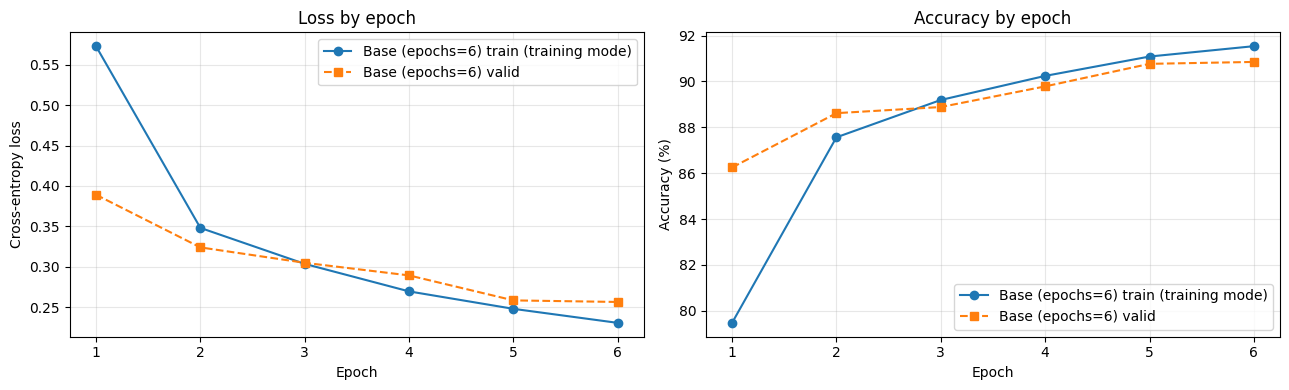

In [12]:
# Base 하나의 train/validation loss와 accuracy 변화를 확인합니다.
plot_comparison([base_result])


# 실험 1 - 적정 Epoch 탐색

## 실험1_변경사항

Base의 다른 조건은 유지하고 **최대 epoch만 6에서 30으로 확장**합니다. 하나의 모델을 30 epoch까지 학습하면서 매 epoch의 validation 지표를 기록합니다.

| 항목 | Base | 실험 1 |
|---|---:|---:|
| 최대 Epoch | 6 | **30** |
| Dropout | 0.0 | 0.0 |
| BatchNorm | 미적용 | 미적용 |
| Learning rate | 0.001 | 0.001 |
| Batch size | 256 | 256 |

독립변수는 최대 학습 횟수 하나입니다. 6, 15, 30 epoch 모델을 따로 학습하지 않고 한 번의 학습 이력에서 적정 시점을 찾습니다.

## 실험1_가설

> Base의 최고 validation accuracy가 마지막 6 epoch에서 기록되었으므로 학습이 충분히 수렴하지 않았을 가능성이 있다. 최대 30 epoch까지 학습하면 validation accuracy가 추가로 향상되지만, 일정 시점 이후에는 train-validation 차이와 validation loss가 증가하며 적정 종료 시점이 나타날 것이다.

## 실험1_실험실행

모델을 30 epoch까지 한 번 학습합니다. 이후 최고 validation accuracy와 최소 validation loss가 기록된 epoch를 각각 계산합니다.

In [13]:
experiment_1_result = run_experiment(
    name="Experiment 1 (epoch search)",
    dropout_rate=0.0,
    epochs=30,  # 탐색할 최대 epoch
    learning_rate=1e-3,
    seed=42,
    use_batchnorm=False,
)


Experiment 1 (epoch search) | Epoch  1/30 | train acc 0.7947 | valid acc 0.8625


Experiment 1 (epoch search) | Epoch  2/30 | train acc 0.8756 | valid acc 0.8862


Experiment 1 (epoch search) | Epoch  3/30 | train acc 0.8919 | valid acc 0.8888


Experiment 1 (epoch search) | Epoch  4/30 | train acc 0.9024 | valid acc 0.8978


Experiment 1 (epoch search) | Epoch  5/30 | train acc 0.9109 | valid acc 0.9077


...

Experiment 1 (epoch search) | Epoch 26/30 | train acc 0.9861 | valid acc 0.9278


Experiment 1 (epoch search) | Epoch 27/30 | train acc 0.9880 | valid acc 0.9252


Experiment 1 (epoch search) | Epoch 28/30 | train acc 0.9903 | valid acc 0.9228


Experiment 1 (epoch search) | Epoch 29/30 | train acc 0.9903 | valid acc 0.9225


Experiment 1 (epoch search) | Epoch 30/30 | train acc 0.9922 | valid acc 0.9245


## 실험1_결과

In [14]:
experiment_1_history = experiment_1_result["history"]
best_accuracy_epoch = experiment_1_result["best_epoch"]
min_loss_epoch = experiment_1_history["valid_loss"].index(
    min(experiment_1_history["valid_loss"])
) + 1
best_accuracy_index = best_accuracy_epoch - 1
min_loss_index = min_loss_epoch - 1

print(f"Best validation accuracy epoch: {best_accuracy_epoch}")
print(f"Best validation accuracy: {experiment_1_result['best_valid_accuracy'] * 100:.2f}%")
print(f"Validation loss at best accuracy epoch: {experiment_1_result['best_valid_loss']:.4f}")
print(f"Minimum validation loss epoch: {min_loss_epoch}")
print(f"Minimum validation loss: {experiment_1_history['valid_loss'][min_loss_index]:.4f}")
print(f"Train accuracy at restored checkpoint (eval mode): {experiment_1_result['train_eval_accuracy'] * 100:.2f}%")
print(f"Validation accuracy at restored checkpoint (eval mode): {experiment_1_result['valid_eval_accuracy'] * 100:.2f}%")
print(f"Train-validation accuracy gap (eval mode): {experiment_1_result['accuracy_gap']:.2f}%p")

Best validation accuracy epoch: 21
Best validation accuracy: 92.98%
Validation loss at best accuracy epoch: 0.2426
Minimum validation loss epoch: 12
Minimum validation loss: 0.2150
Train accuracy at restored checkpoint (eval mode): 98.25%
Validation accuracy at restored checkpoint (eval mode): 92.98%
Train-validation accuracy gap (eval mode): 5.27%p


## 실험1_해석

- 가설 판단: 지지됨
- 최고 validation accuracy는 21 epoch에서 92.98%로 나타났습니다.
- validation loss는 12 epoch에서 먼저 최솟값을 기록했습니다.
- 21 epoch의 가중치를 복원한 뒤 평가 모드로 다시 측정한 train-validation accuracy 차이는 5.27%p입니다.
- 실험 1 결론: 분류 정확도를 주 지표로 사용하여 이후 비교 실험의 학습 횟수를 21 epoch로 고정합니다.

In [15]:
selected_epochs = best_accuracy_epoch

## 실험1_시각화

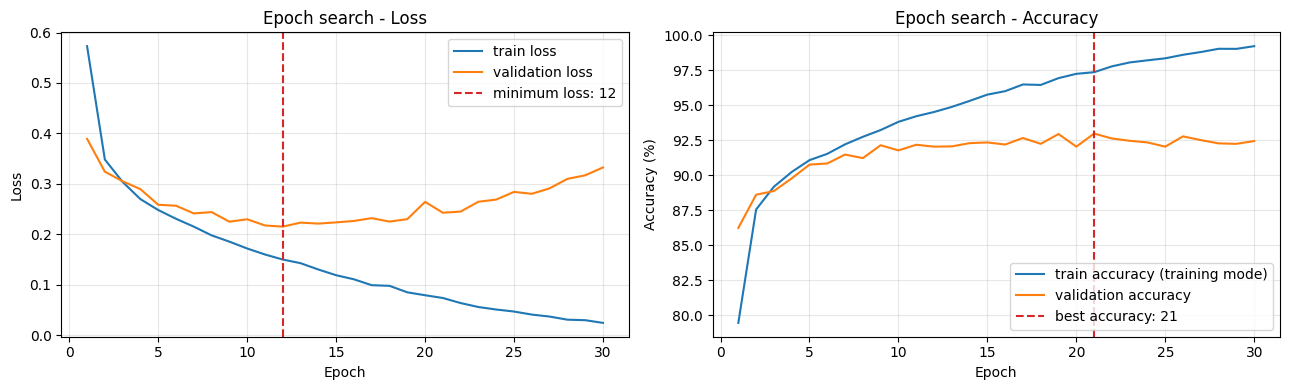

In [16]:
epochs = range(1, experiment_1_result["epochs"] + 1)
history = experiment_1_result["history"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs, history["train_loss"], label="train loss")
axes[0].plot(epochs, history["valid_loss"], label="validation loss")
axes[0].axvline(min_loss_epoch, color="tab:red", linestyle="--", label=f"minimum loss: {min_loss_epoch}")
axes[0].set(title="Epoch search - Loss", xlabel="Epoch", ylabel="Loss")

axes[1].plot(epochs, [v * 100 for v in history["train_accuracy"]], label="train accuracy (training mode)")
axes[1].plot(epochs, [v * 100 for v in history["valid_accuracy"]], label="validation accuracy")
axes[1].axvline(best_accuracy_epoch, color="tab:red", linestyle="--", label=f"best accuracy: {best_accuracy_epoch}")
axes[1].set(title="Epoch search - Accuracy", xlabel="Epoch", ylabel="Accuracy (%)")

for axis in axes:
    axis.grid(alpha=0.3)
    axis.legend()
plt.tight_layout()
plt.show()


# 실험 2 - 적정 Dropout 탐색

## 실험2_변경사항

실험 1에서 선택한 epoch를 고정하고, **Dropout 비율만 여러 후보로 변경**합니다.

- 후보: `0.0`, `0.1`, `0.2`, `0.3`, `0.4`
- 고정: CNN 구조, BatchNorm 미적용, Adam, learning rate 0.001, batch size 256, seed 42

여러 값을 실행하지만 변경하는 독립변수는 Dropout 하나이므로 하나의 실험으로 취급합니다. 각 후보는 서로 다른 학습 과정이므로 새 모델로 각각 학습합니다.

## 실험2_가설

> Dropout을 적용하면 Fully Connected Layer가 특정 특징에 과도하게 의존하는 현상이 줄어 validation loss와 train-validation 차이가 감소할 것이다. 너무 높은 비율은 필요한 특징 학습까지 방해하므로, 후보 중 중간 범위에서 가장 좋은 validation 성능이 나타날 것이다.

## 실험2_실험실행

동일한 함수와 seed를 사용해 다섯 개 Dropout 후보를 순서대로 학습합니다. 후보별 최고 validation accuracy 가중치를 기록합니다.

In [17]:
dropout_candidates = [0.0, 0.1, 0.2, 0.3, 0.4]

# Dropout 0.0은 실험 1과 동일한 모델이므로 선택된 epoch까지의 결과를 재사용합니다.
no_dropout_result = copy.deepcopy(experiment_1_result)
no_dropout_result["name"] = "Dropout 0.0"
no_dropout_result["epochs"] = selected_epochs
no_dropout_result["history"] = {
    key: values[:selected_epochs]
    for key, values in experiment_1_result["history"].items()
}
no_dropout_result["best_valid_accuracy"] = max(
    no_dropout_result["history"]["valid_accuracy"]
)
no_dropout_result["best_epoch"] = (
    no_dropout_result["history"]["valid_accuracy"].index(
        no_dropout_result["best_valid_accuracy"]
    ) + 1
)

dropout_results = {0.0: no_dropout_result}

for dropout_rate in dropout_candidates[1:]:
    print(f"\n===== Dropout {dropout_rate:.1f} =====")
    dropout_results[dropout_rate] = run_experiment(
        name=f"Dropout {dropout_rate:.1f}",
        dropout_rate=dropout_rate,
        epochs=selected_epochs,
        learning_rate=1e-3,
        seed=42,
        use_batchnorm=False,
    )



===== Dropout 0.1 =====


Dropout 0.1 | Epoch  1/21 | train acc 0.7875 | valid acc 0.8665


Dropout 0.1 | Epoch  2/21 | train acc 0.8712 | valid acc 0.8862


Dropout 0.1 | Epoch  3/21 | train acc 0.8884 | valid acc 0.8835


Dropout 0.1 | Epoch  4/21 | train acc 0.9007 | valid acc 0.9008


...

Dropout 0.4 | Epoch 17/21 | train acc 0.9421 | valid acc 0.9262


Dropout 0.4 | Epoch 18/21 | train acc 0.9444 | valid acc 0.9273


Dropout 0.4 | Epoch 19/21 | train acc 0.9476 | valid acc 0.9260


Dropout 0.4 | Epoch 20/21 | train acc 0.9487 | valid acc 0.9262


Dropout 0.4 | Epoch 21/21 | train acc 0.9505 | valid acc 0.9240


## 실험2_결과

In [18]:
dropout_summary = []

for dropout_rate, result in dropout_results.items():
    valid_loss = result["best_valid_loss"]
    accuracy_gap = result["accuracy_gap"]
    dropout_summary.append({
        "dropout": dropout_rate,
        "best_epoch": result["best_epoch"],
        "valid_accuracy": result["best_valid_accuracy"],
        "valid_loss": valid_loss,
        "accuracy_gap": accuracy_gap,
    })

print(f"{'Dropout':>8} {'Best epoch':>11} {'Valid acc':>11} {'Valid loss':>11} {'Gap':>9}")
print("-" * 56)
for row in dropout_summary:
    print(
        f"{row['dropout']:>8.1f} {row['best_epoch']:>11d} "
        f"{row['valid_accuracy'] * 100:>10.2f}% {row['valid_loss']:>11.4f} "
        f"{row['accuracy_gap']:>8.2f}%p"
    )

# 최고 정확도에서 0.1%p 이내인 후보는 동급으로 보고 validation loss로 최종 선택합니다.
maximum_accuracy = max(row["valid_accuracy"] for row in dropout_summary)
near_best_candidates = [
    row for row in dropout_summary
    if maximum_accuracy - row["valid_accuracy"] <= 0.001
]
selected_dropout_row = min(
    near_best_candidates,
    key=lambda row: (row["valid_loss"], row["accuracy_gap"], row["dropout"]),
)
selected_dropout = selected_dropout_row["dropout"]
selected_dropout_result = dropout_results[selected_dropout]

print(f"\nSelected dropout: {selected_dropout:.1f}")


 Dropout  Best epoch   Valid acc  Valid loss       Gap
--------------------------------------------------------
     0.0          21      92.98%      0.2426     5.27%p
     0.1          13      92.83%      0.2090     3.12%p
     0.2          18      92.95%      0.2146     3.99%p
     0.3          18      92.63%      0.2082     4.02%p
     0.4          18      92.73%      0.2062     3.59%p

Selected dropout: 0.2


## 실험2_해석

- 가장 높은 accuracy에서 0.1%p 이내인 후보 중 validation loss가 가장 낮은 값은 Dropout 0.2입니다.
- Dropout 0.0 대비 validation accuracy 변화는 -0.03%p입니다.
- Dropout 0.0 대비 validation loss 변화는 -0.0280입니다.
- 복원된 동일 checkpoint를 평가 모드로 비교했을 때 train-validation 차이는 5.27%p에서 3.99%p로 1.28%p 감소했습니다.
- 실험 2 결론: 이후 실험의 Dropout 비율을 0.2로 고정합니다.

## 실험2_시각화

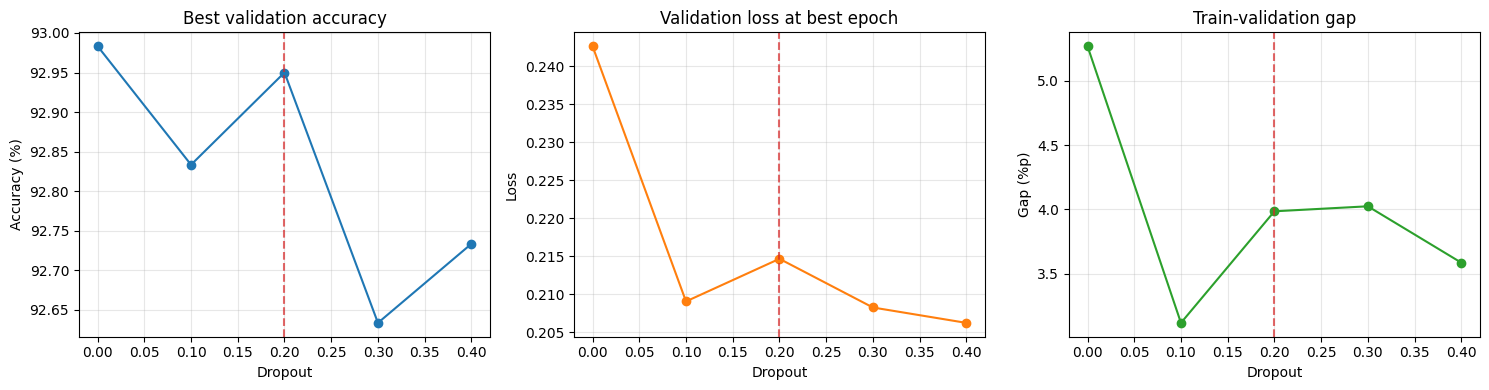

In [19]:
rates = [row["dropout"] for row in dropout_summary]
accuracies = [row["valid_accuracy"] * 100 for row in dropout_summary]
losses = [row["valid_loss"] for row in dropout_summary]
gaps = [row["accuracy_gap"] for row in dropout_summary]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(rates, accuracies, marker="o")
axes[0].set(title="Best validation accuracy", xlabel="Dropout", ylabel="Accuracy (%)")
axes[1].plot(rates, losses, marker="o", color="tab:orange")
axes[1].set(title="Validation loss at best epoch", xlabel="Dropout", ylabel="Loss")
axes[2].plot(rates, gaps, marker="o", color="tab:green")
axes[2].set(title="Train-validation gap", xlabel="Dropout", ylabel="Gap (%p)")

for axis in axes:
    axis.axvline(selected_dropout, color="tab:red", linestyle="--", alpha=0.7)
    axis.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# 실험 3 - BatchNorm 적용

## 실험3_변경사항

실험 1과 2에서 선택한 `epochs=21`, `Dropout=0.2`를 유지하고, 각 합성곱 층 뒤에 **BatchNorm만 추가**합니다.

| 항목 | 실험 2 채택 모델 | 실험 3 |
|---|---:|---:|
| Epoch | 21 | 21 |
| Dropout | 0.2 | 0.2 |
| BatchNorm | 미적용 | **적용** |
| Learning rate | 0.001 | 0.001 |
| Batch size | 256 | 256 |

독립변수는 BatchNorm 적용 여부 하나이며, 다른 조건은 동일합니다.

## 실험3_가설

> BatchNorm을 합성곱 층 뒤에 적용하면 mini-batch 단위로 중간 특징의 분포가 정규화되어 학습이 안정화될 것이다. 이에 따라 Dropout 0.2만 적용한 모델보다 validation accuracy가 향상되거나 validation loss가 감소할 것이다.

BatchNorm은 규제 효과도 일부 가질 수 있지만, 이 실험에서는 학습 안정화와 검증 성능 변화를 중심으로 평가합니다.

## 실험3_실험실행

실험 2에서 선택된 Dropout 0.2 모델과 동일한 조건에서 `use_batchnorm=True`만 적용해 모델을 처음부터 학습합니다.

In [20]:
experiment_3_result = run_experiment(
    name="Experiment 3 (BatchNorm)",
    dropout_rate=selected_dropout,
    epochs=selected_epochs,
    learning_rate=1e-3,
    seed=42,
    use_batchnorm=True,  # 실험 2 채택 모델에서 변경한 유일한 조건
)


Experiment 3 (BatchNorm) | Epoch  1/21 | train acc 0.8336 | valid acc 0.8887


Experiment 3 (BatchNorm) | Epoch  2/21 | train acc 0.8924 | valid acc 0.9022


Experiment 3 (BatchNorm) | Epoch  3/21 | train acc 0.9079 | valid acc 0.8990


Experiment 3 (BatchNorm) | Epoch  4/21 | train acc 0.9170 | valid acc 0.9108


Experiment 3 (BatchNorm) | Epoch  5/21 | train acc 0.9244 | valid acc 0.9148


...

Experiment 3 (BatchNorm) | Epoch 17/21 | train acc 0.9711 | valid acc 0.9227


Experiment 3 (BatchNorm) | Epoch 18/21 | train acc 0.9711 | valid acc 0.9250


Experiment 3 (BatchNorm) | Epoch 19/21 | train acc 0.9743 | valid acc 0.9250


Experiment 3 (BatchNorm) | Epoch 20/21 | train acc 0.9754 | valid acc 0.9242


Experiment 3 (BatchNorm) | Epoch 21/21 | train acc 0.9786 | valid acc 0.9247


## 실험3_결과

In [21]:
reference_result = selected_dropout_result
reference_history = reference_result["history"]
experiment_3_history = experiment_3_result["history"]

reference_loss = reference_result["best_valid_loss"]
experiment_3_loss = experiment_3_result["best_valid_loss"]
reference_gap = reference_result["accuracy_gap"]
experiment_3_gap = experiment_3_result["accuracy_gap"]

validation_accuracy_change = (
    experiment_3_result["best_valid_accuracy"]
    - reference_result["best_valid_accuracy"]
) * 100
validation_loss_change = experiment_3_loss - reference_loss
gap_change = experiment_3_gap - reference_gap

print("[Experiment 2 selected - BatchNorm OFF]")
print(f"Dropout: {selected_dropout:.1f}")
print(f"Best epoch: {reference_result['best_epoch']}")
print(f"Best validation accuracy: {reference_result['best_valid_accuracy'] * 100:.2f}%")
print(f"Validation loss at best epoch: {reference_loss:.4f}")
print(f"Train-validation accuracy gap: {reference_gap:.2f}%p")

print("\n[Experiment 3 - BatchNorm ON]")
print(f"Dropout: {selected_dropout:.1f}")
print(f"Best epoch: {experiment_3_result['best_epoch']}")
print(f"Best validation accuracy: {experiment_3_result['best_valid_accuracy'] * 100:.2f}%")
print(f"Validation loss at best epoch: {experiment_3_loss:.4f}")
print(f"Train-validation accuracy gap: {experiment_3_gap:.2f}%p")
print(f"Validation accuracy change: {validation_accuracy_change:+.2f}%p")
print(f"Validation loss change: {validation_loss_change:+.4f}")
print(f"Accuracy gap change: {gap_change:+.2f}%p")


[Experiment 2 selected - BatchNorm OFF]
Dropout: 0.2
Best epoch: 18
Best validation accuracy: 92.95%
Validation loss at best epoch: 0.2146
Train-validation accuracy gap: 3.99%p

[Experiment 3 - BatchNorm ON]
Dropout: 0.2
Best epoch: 15
Best validation accuracy: 92.55%
Validation loss at best epoch: 0.2388
Train-validation accuracy gap: 5.17%p
Validation accuracy change: -0.40%p
Validation loss change: +0.0241
Accuracy gap change: +1.19%p


## 실험3_해석

- 가설 판단: 지지되지 않음
- BatchNorm 적용 후 최고 validation accuracy 변화는 -0.40%p입니다.
- validation loss는 0.0241 증가했습니다.
- 평가 모드로 다시 측정한 train-validation 차이는 1.19%p 증가했습니다.
- 실험 3 결론: BatchNorm을 채택하지 않고 실험 2의 설정을 유지합니다.

## 실험3_시각화

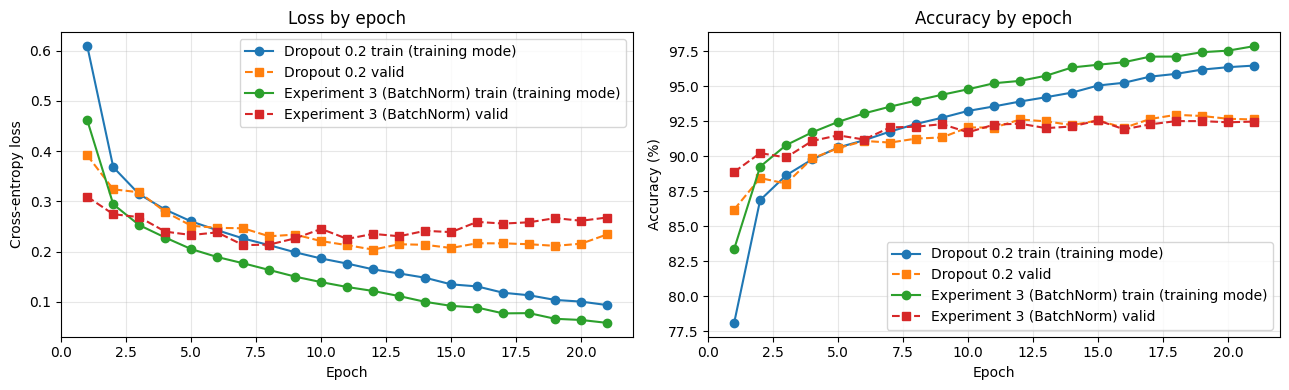

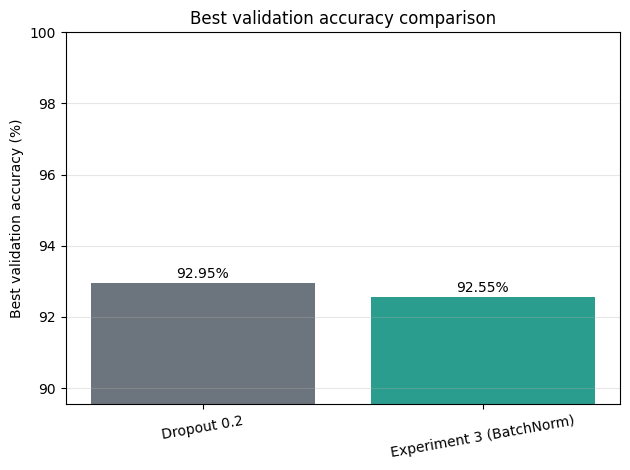

In [22]:
batchnorm_results = [reference_result, experiment_3_result]

# BatchNorm 적용 전후의 epoch별 학습 곡선 비교
plot_comparison(batchnorm_results)

# BatchNorm 적용 전후의 최고 validation accuracy 비교
plot_best_valid_accuracy(batchnorm_results)


# 실험 4 - Layer 너비 탐색

## 실험4_변경사항

실험 2에서 채택하고 실험 3에서도 유지하기로 한 설정을 기준 모델로 사용합니다.

- Epoch: 21
- Dropout: 0.2
- BatchNorm: 미적용
- Optimizer: Adam
- Learning rate: 0.001

이번에는 **Fully Connected Layer의 hidden unit 수만 변경**합니다.

- 후보: `64`, `128`, `256`
- 현재 기준값: `128`

여러 후보를 한 번에 학습하지만 변경하는 독립변수는 Layer 너비 하나입니다. 합성곱 층, Dropout, optimizer 등 다른 조건은 동일하게 유지합니다.

## 실험4_가설

> 현재 모델은 학습 데이터와 검증 데이터 사이에 성능 차이가 남아 있다. Fully Connected Layer의 hidden unit을 128보다 작은 64로 줄이면 모델의 표현 용량과 파라미터 수가 감소해 과적합이 완화될 수 있다. 반대로 256으로 늘리면 표현력은 증가하지만 과적합이 심해질 가능성이 있다. 따라서 64 또는 128에서 validation accuracy와 validation loss의 균형이 가장 좋을 것이다.

최고 validation accuracy를 주 지표로 평가하고, validation loss, train-validation 차이, 전체 파라미터 수를 보조 지표로 비교합니다.

## 실험4_실험실행

hidden unit `64`, `128`, `256` 모델을 동일한 조건으로 각각 처음부터 학습합니다. 각 후보별 최고 validation accuracy 가중치를 기록합니다.

In [23]:
hidden_dim_candidates = [64, 128, 256]
layer_results = {}

for hidden_dim in hidden_dim_candidates:
    print(f"\n===== Hidden units {hidden_dim} =====")
    layer_results[hidden_dim] = run_experiment(
        name=f"Hidden units {hidden_dim}",
        dropout_rate=0.2,
        epochs=21,
        learning_rate=1e-3,
        seed=42,
        use_batchnorm=False,
        hidden_dim=hidden_dim,
    )



===== Hidden units 64 =====


Hidden units 64 | Epoch  1/21 | train acc 0.7556 | valid acc 0.8565


Hidden units 64 | Epoch  2/21 | train acc 0.8557 | valid acc 0.8740


Hidden units 64 | Epoch  3/21 | train acc 0.8737 | valid acc 0.8833


Hidden units 64 | Epoch  4/21 | train acc 0.8849 | valid acc 0.8925


...

Hidden units 256 | Epoch 17/21 | train acc 0.9679 | valid acc 0.9262


Hidden units 256 | Epoch 18/21 | train acc 0.9713 | valid acc 0.9305


Hidden units 256 | Epoch 19/21 | train acc 0.9735 | valid acc 0.9295


Hidden units 256 | Epoch 20/21 | train acc 0.9776 | valid acc 0.9293


Hidden units 256 | Epoch 21/21 | train acc 0.9788 | valid acc 0.9265


## 실험4_결과

In [24]:
layer_summary = []

for hidden_dim, result in layer_results.items():
    valid_loss = result["best_valid_loss"]
    accuracy_gap = result["accuracy_gap"]
    parameter_count = sum(
        parameter.numel() for parameter in result["model"].parameters()
    )
    layer_summary.append({
        "hidden_dim": hidden_dim,
        "best_epoch": result["best_epoch"],
        "valid_accuracy": result["best_valid_accuracy"],
        "valid_loss": valid_loss,
        "accuracy_gap": accuracy_gap,
        "parameters": parameter_count,
    })

print(
    f"{'Hidden':>8} {'Best epoch':>11} {'Valid acc':>11} "
    f"{'Valid loss':>11} {'Gap':>9} {'Parameters':>12}"
)
print("-" * 72)
for row in layer_summary:
    print(
        f"{row['hidden_dim']:>8d} {row['best_epoch']:>11d} "
        f"{row['valid_accuracy'] * 100:>10.2f}% {row['valid_loss']:>11.4f} "
        f"{row['accuracy_gap']:>8.2f}%p {row['parameters']:>12,d}"
    )

# 최고 정확도에서 0.1%p 이내인 후보는 동급으로 보고,
# validation loss가 낮고 파라미터 수가 적은 모델을 선택합니다.
maximum_accuracy = max(row["valid_accuracy"] for row in layer_summary)
near_best_layers = [
    row for row in layer_summary
    if maximum_accuracy - row["valid_accuracy"] <= 0.001
]
selected_layer_row = min(
    near_best_layers,
    key=lambda row: (row["valid_loss"], row["parameters"]),
)
selected_hidden_dim = selected_layer_row["hidden_dim"]
selected_layer_result = layer_results[selected_hidden_dim]

print(f"\nSelected hidden units: {selected_hidden_dim}")


  Hidden  Best epoch   Valid acc  Valid loss       Gap   Parameters
------------------------------------------------------------------------
      64          21      92.67%      0.2279     4.16%p      220,234
     128          18      92.95%      0.2146     3.99%p      421,642
     256          14      93.15%      0.2170     3.80%p      824,458

Selected hidden units: 256


## 실험4_해석

- 최고 정확도에서 0.1%p 이내인 후보 중 균형이 가장 좋은 값은 hidden unit 256입니다.
- 기준값 128 대비 validation accuracy 변화는 +0.20%p, validation loss 변화는 +0.0024입니다.
- 평가 모드로 다시 측정한 train-validation 차이는 0.19%p 감소했습니다.
- 전체 파라미터 수 변화는 +402,816개(+95.5%)입니다.
- 가설 판단: 지지되지 않음
- 실험 4 결론: 더 큰 hidden unit 256을 채택합니다.

## 실험4_시각화

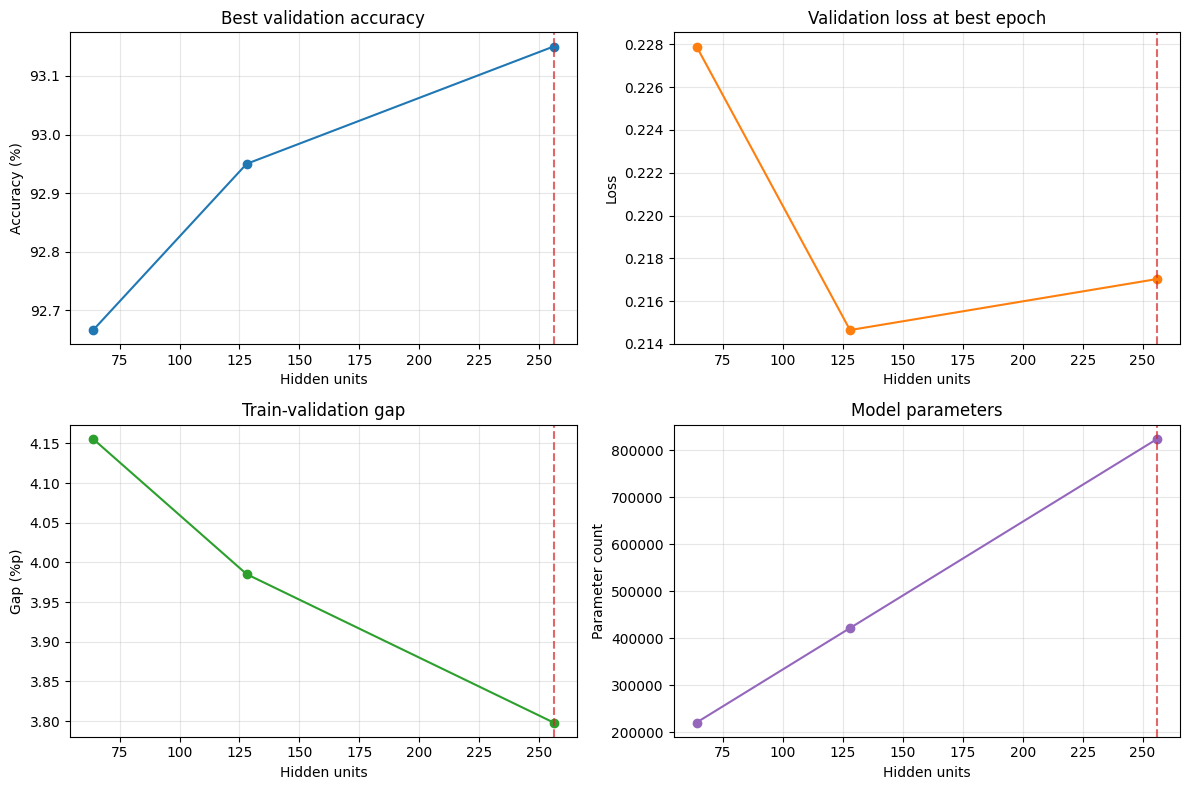

In [25]:
hidden_dims = [row["hidden_dim"] for row in layer_summary]
accuracies = [row["valid_accuracy"] * 100 for row in layer_summary]
losses = [row["valid_loss"] for row in layer_summary]
gaps = [row["accuracy_gap"] for row in layer_summary]
parameters = [row["parameters"] for row in layer_summary]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].plot(hidden_dims, accuracies, marker="o")
axes[0, 0].set(title="Best validation accuracy", ylabel="Accuracy (%)")
axes[0, 1].plot(hidden_dims, losses, marker="o", color="tab:orange")
axes[0, 1].set(title="Validation loss at best epoch", ylabel="Loss")
axes[1, 0].plot(hidden_dims, gaps, marker="o", color="tab:green")
axes[1, 0].set(title="Train-validation gap", ylabel="Gap (%p)")
axes[1, 1].plot(hidden_dims, parameters, marker="o", color="tab:purple")
axes[1, 1].set(title="Model parameters", ylabel="Parameter count")

for axis in axes.flat:
    axis.axvline(selected_hidden_dim, color="tab:red", linestyle="--", alpha=0.7)
    axis.set_xlabel("Hidden units")
    axis.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# 실험 5 - Optimizer 탐색

## 실험5_변경사항

실험 4에서 선택한 `hidden_dim=256`과 기존 채택 설정을 유지하고 **Optimizer 종류만 변경**합니다.

- 후보: `Adam`, `AdamW`, `RMSprop`
- 공통 learning rate: 0.001
- 고정 조건: epoch 21, Dropout 0.2, BatchNorm 미적용, ReLU, hidden unit 256

변경하는 독립변수는 Optimizer 하나입니다.

## 실험5_가설

> 같은 learning rate에서도 Optimizer마다 gradient의 이동 평균과 파라미터 갱신 방식이 다르므로 수렴 속도와 일반화 성능이 달라질 것이다. AdamW 또는 RMSprop이 Adam보다 validation accuracy나 validation loss를 개선할 가능성이 있다.

모든 후보는 동일한 learning rate 조건에서 비교합니다.

## 실험5_실험실행

세 Optimizer 후보를 동일한 초기 조건으로 각각 학습합니다.

In [26]:
optimizer_candidates = ["Adam", "AdamW", "RMSprop"]
optimizer_results = {}

for optimizer_name in optimizer_candidates:
    print(f"\n===== Optimizer {optimizer_name} =====")
    optimizer_results[optimizer_name] = run_experiment(
        name=f"Optimizer {optimizer_name}", dropout_rate=0.2,
        epochs=21, learning_rate=1e-3, seed=42,
        use_batchnorm=False, hidden_dim=256,
        activation_name="ReLU", optimizer_name=optimizer_name,
    )



===== Optimizer Adam =====


Optimizer Adam | Epoch  1/21 | train acc 0.7962 | valid acc 0.8683


Optimizer Adam | Epoch  2/21 | train acc 0.8761 | valid acc 0.8860


Optimizer Adam | Epoch  3/21 | train acc 0.8916 | valid acc 0.8973


Optimizer Adam | Epoch  4/21 | train acc 0.9035 | valid acc 0.9045


...

Optimizer RMSprop | Epoch 17/21 | train acc 0.9666 | valid acc 0.9233


Optimizer RMSprop | Epoch 18/21 | train acc 0.9706 | valid acc 0.9222


Optimizer RMSprop | Epoch 19/21 | train acc 0.9721 | valid acc 0.9215


Optimizer RMSprop | Epoch 20/21 | train acc 0.9750 | valid acc 0.9210


Optimizer RMSprop | Epoch 21/21 | train acc 0.9772 | valid acc 0.9188


## 실험5_결과

In [27]:
optimizer_summary = []
for optimizer_name, result in optimizer_results.items():
    optimizer_summary.append({
        "optimizer": optimizer_name,
        "best_epoch": result["best_epoch"],
        "accuracy": result["best_valid_accuracy"],
        "loss": result["best_valid_loss"],
        "gap": result["accuracy_gap"],
    })

print(f"{'Optimizer':>10} {'Epoch':>7} {'Valid acc':>11} {'Valid loss':>11} {'Gap':>9}")
print("-" * 54)
for row in optimizer_summary:
    print(f"{row['optimizer']:>10} {row['best_epoch']:>7d} {row['accuracy']*100:>10.2f}% {row['loss']:>11.4f} {row['gap']:>8.2f}%p")

maximum_accuracy = max(row["accuracy"] for row in optimizer_summary)
near_best = [row for row in optimizer_summary if maximum_accuracy-row["accuracy"] <= 0.001]
selected_optimizer_row = min(near_best, key=lambda row: (row["loss"], row["gap"]))
selected_optimizer = selected_optimizer_row["optimizer"]
selected_optimizer_result = optimizer_results[selected_optimizer]
print(f"\nSelected optimizer: {selected_optimizer}")


 Optimizer   Epoch   Valid acc  Valid loss       Gap
------------------------------------------------------
      Adam      14      93.15%      0.2170     3.80%p
     AdamW      12      92.90%      0.2023     3.47%p
   RMSprop      16      92.37%      0.2319     5.44%p

Selected optimizer: Adam


## 실험5_해석

- 최고 정확도에서 0.1%p 이내인 후보 중 선택된 Optimizer는 Adam입니다.
- Adam 대비 validation accuracy와 validation loss 변화는 없습니다.
- 평가 모드로 다시 측정한 train-validation 차이 변화도 없습니다.
- 가설 판단: 지지되지 않음
- 실험 5 결론: 이후 실험의 Optimizer를 Adam으로 고정합니다.

## 실험5_시각화

Optimizer별 최고 검증 정확도, 검증 손실, 일반화 차이를 비교합니다.

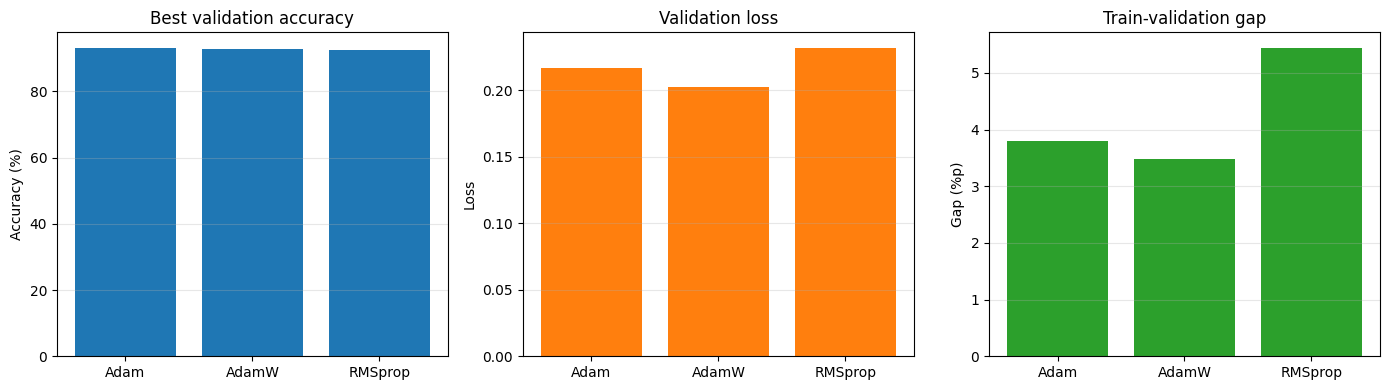

In [28]:
names=[row["optimizer"] for row in optimizer_summary]
fig,axes=plt.subplots(1,3,figsize=(14,4))
axes[0].bar(names,[row["accuracy"]*100 for row in optimizer_summary])
axes[0].set(title="Best validation accuracy",ylabel="Accuracy (%)")
axes[1].bar(names,[row["loss"] for row in optimizer_summary],color="tab:orange")
axes[1].set(title="Validation loss",ylabel="Loss")
axes[2].bar(names,[row["gap"] for row in optimizer_summary],color="tab:green")
axes[2].set(title="Train-validation gap",ylabel="Gap (%p)")
for axis in axes: axis.grid(axis="y",alpha=0.3)
plt.tight_layout(); plt.show()


# 실험 6 - Activation 탐색

## 실험6_변경사항

실험 5에서 선택된 Optimizer를 사용하고 **Activation 함수만 변경**합니다.

- 후보: `ReLU`, `LeakyReLU`, `GELU`
- 고정 조건: epoch 21, Dropout 0.2, BatchNorm 미적용, hidden unit 256

합성곱 블록과 Fully Connected Layer에 동일한 Activation 후보를 적용합니다.

## 실험6_가설

> ReLU는 음수 영역의 gradient가 0이지만 LeakyReLU는 작은 음수 gradient를 유지하고, GELU는 입력을 부드럽게 조절한다. 따라서 Activation에 따라 학습 흐름과 validation 성능이 달라지며 LeakyReLU 또는 GELU가 ReLU보다 안정적인 일반화 성능을 보일 수 있다.

## 실험6_실험실행

실험 5에서 선택된 Optimizer를 고정하고 세 Activation 후보를 각각 학습합니다.

In [29]:
activation_candidates = ["ReLU", "LeakyReLU", "GELU"]
activation_results = {}

for activation_name in activation_candidates:
    print(f"\n===== Activation {activation_name} =====")
    activation_results[activation_name] = run_experiment(
        name=f"Activation {activation_name}", dropout_rate=0.2,
        epochs=21, learning_rate=1e-3, seed=42,
        use_batchnorm=False, hidden_dim=256,
        activation_name=activation_name, optimizer_name=selected_optimizer,
    )



===== Activation ReLU =====


Activation ReLU | Epoch  1/21 | train acc 0.7962 | valid acc 0.8683


Activation ReLU | Epoch  2/21 | train acc 0.8761 | valid acc 0.8860


Activation ReLU | Epoch  3/21 | train acc 0.8916 | valid acc 0.8973


Activation ReLU | Epoch  4/21 | train acc 0.9035 | valid acc 0.9045


...

Activation GELU | Epoch 17/21 | train acc 0.9858 | valid acc 0.9250


Activation GELU | Epoch 18/21 | train acc 0.9886 | valid acc 0.9252


Activation GELU | Epoch 19/21 | train acc 0.9882 | valid acc 0.9265


Activation GELU | Epoch 20/21 | train acc 0.9919 | valid acc 0.9297


Activation GELU | Epoch 21/21 | train acc 0.9917 | valid acc 0.9255


## 실험6_결과

In [30]:
activation_summary=[]
for activation_name,result in activation_results.items():
    activation_summary.append({
        "activation":activation_name,"best_epoch":result["best_epoch"],
        "accuracy":result["best_valid_accuracy"],"loss":result["best_valid_loss"],
        "gap":result["accuracy_gap"],
    })
print(f"{'Activation':>12} {'Epoch':>7} {'Valid acc':>11} {'Valid loss':>11} {'Gap':>9}")
print("-"*56)
for row in activation_summary:
    print(f"{row['activation']:>12} {row['best_epoch']:>7d} {row['accuracy']*100:>10.2f}% {row['loss']:>11.4f} {row['gap']:>8.2f}%p")
maximum_accuracy=max(row["accuracy"] for row in activation_summary)
near_best=[row for row in activation_summary if maximum_accuracy-row["accuracy"]<=0.001]
selected_activation_row=min(near_best,key=lambda row:(row["loss"],row["gap"]))
selected_activation=selected_activation_row["activation"]
selected_activation_result=activation_results[selected_activation]
print(f"\nSelected activation: {selected_activation}")


  Activation   Epoch   Valid acc  Valid loss       Gap
--------------------------------------------------------
        ReLU      14      93.15%      0.2170     3.80%p
   LeakyReLU      12      92.87%      0.2089     4.20%p
        GELU      20      92.97%      0.2968     6.68%p

Selected activation: ReLU


## 실험6_해석

- 선택된 Activation은 ReLU입니다.
- ReLU 대비 validation accuracy와 validation loss 변화는 없습니다.
- 평가 모드로 다시 측정한 train-validation 차이 변화도 없습니다.
- 가설 판단: 지지되지 않음
- 실험 6 결론: 이후 실험의 Activation을 ReLU로 고정합니다.

## 실험6_시각화

Activation별 최고 검증 정확도, 검증 손실, 일반화 차이를 비교합니다.

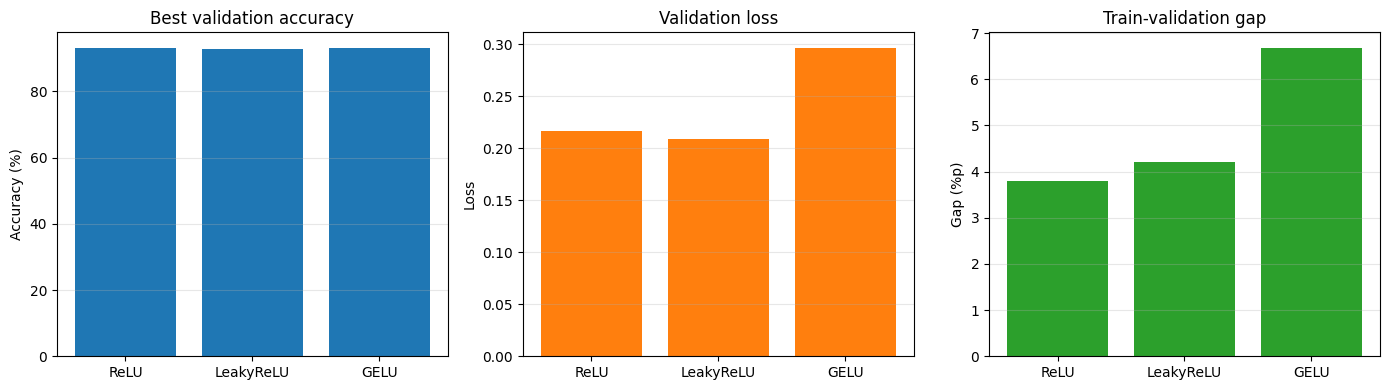

In [31]:
names=[row["activation"] for row in activation_summary]
fig,axes=plt.subplots(1,3,figsize=(14,4))
axes[0].bar(names,[row["accuracy"]*100 for row in activation_summary])
axes[0].set(title="Best validation accuracy",ylabel="Accuracy (%)")
axes[1].bar(names,[row["loss"] for row in activation_summary],color="tab:orange")
axes[1].set(title="Validation loss",ylabel="Loss")
axes[2].bar(names,[row["gap"] for row in activation_summary],color="tab:green")
axes[2].set(title="Train-validation gap",ylabel="Gap (%p)")
for axis in axes: axis.grid(axis="y",alpha=0.3)
plt.tight_layout(); plt.show()


# 실험 7 - Early Stopping 탐색

## 실험7_변경사항

실험 6에서 선택된 모델에 **Early Stopping 조건만 변경**합니다.

- 후보: 미적용, `patience=3`, `patience=5`
- `min_delta=0.001`
- 최대 epoch: 21

validation loss가 0.001 이상 개선되지 않는 epoch가 patience만큼 연속되면 학습을 종료합니다.

## 실험7_가설

> validation loss가 정체된 뒤 학습을 계속하면 과적합과 불필요한 계산이 증가한다. Early Stopping을 적용하면 최고 validation accuracy를 크게 훼손하지 않으면서 실제 학습 epoch와 과적합을 줄일 수 있을 것이다. patience 3은 빠르지만 너무 일찍 멈출 수 있고, patience 5는 더 안정적으로 개선 기회를 기다릴 것이다.

## 실험7_실험실행

Early Stopping 미적용과 patience 3·5를 같은 최대 21 epoch 조건에서 비교합니다. 세 후보 모두 validation loss가 가장 낮은 checkpoint를 저장·복원하여 중단 기준과 모델 복원 기준을 일치시킵니다.

In [32]:
patience_candidates = [None, 3, 5]
early_stopping_results = {}

for patience in patience_candidates:
    label = "OFF" if patience is None else f"patience={patience}"
    print(f"\n===== Early Stopping {label} =====")
    early_stopping_results[label] = run_experiment(
        name=f"Early Stopping {label}", dropout_rate=0.2,
        epochs=21, learning_rate=1e-3, seed=42,
        use_batchnorm=False, hidden_dim=256,
        activation_name=selected_activation, optimizer_name=selected_optimizer,
        early_stopping_patience=patience, min_delta=0.001,
        checkpoint_metric="loss",
    )



===== Early Stopping OFF =====


Early Stopping OFF | Epoch  1/21 | train acc 0.7962 | valid acc 0.8683


Early Stopping OFF | Epoch  2/21 | train acc 0.8761 | valid acc 0.8860


Early Stopping OFF | Epoch  3/21 | train acc 0.8916 | valid acc 0.8973


Early Stopping OFF | Epoch  4/21 | train acc 0.9035 | valid acc 0.9045


...

Early Stopping patience=5 | Epoch 13/21 | train acc 0.9533 | valid acc 0.9245


Early Stopping patience=5 | Epoch 14/21 | train acc 0.9580 | valid acc 0.9315


Early Stopping patience=5 | Epoch 15/21 | train acc 0.9622 | valid acc 0.9217


Early Stopping patience=5 | Epoch 16/21 | train acc 0.9646 | valid acc 0.9288


Early Stopping patience=5 | Epoch 17/21 | train acc 0.9679 | valid acc 0.9262
Early Stopping patience=5 | Early stopping at epoch 17 (patience=5)


## 실험7_결과

In [33]:
early_stopping_summary=[]
for label,result in early_stopping_results.items():
    early_stopping_summary.append({
        "setting":label,"epochs_ran":result["epochs_ran"],"best_epoch":result["best_epoch"],
        "accuracy":result["best_valid_accuracy"],"loss":result["best_valid_loss"],
        "gap":result["accuracy_gap"],
    })
print(f"{'Setting':>12} {'Ran':>5} {'Best':>6} {'Valid acc':>11} {'Valid loss':>11} {'Gap':>9}")
print("-"*64)
for row in early_stopping_summary:
    print(f"{row['setting']:>12} {row['epochs_ran']:>5d} {row['best_epoch']:>6d} {row['accuracy']*100:>10.2f}% {row['loss']:>11.4f} {row['gap']:>8.2f}%p")
maximum_accuracy=max(row["accuracy"] for row in early_stopping_summary)
near_best=[row for row in early_stopping_summary if maximum_accuracy-row["accuracy"]<=0.001]
selected_early_stopping_row=min(near_best,key=lambda row:(row["epochs_ran"],row["loss"]))
selected_early_stopping=selected_early_stopping_row["setting"]
selected_early_stopping_result=early_stopping_results[selected_early_stopping]
print(f"\nSelected early stopping: {selected_early_stopping}")


     Setting   Ran   Best   Valid acc  Valid loss       Gap
----------------------------------------------------------------
         OFF    21     12      92.60%      0.2055     3.61%p
  patience=3    15     12      92.60%      0.2055     3.61%p
  patience=5    17     12      92.60%      0.2055     3.61%p

Selected early stopping: patience=3


## 실험7_해석

- 세 후보 모두 validation loss가 가장 낮았던 12 epoch의 checkpoint를 복원했습니다.
- 선택된 설정은 patience=3이며, 미적용과 같은 validation accuracy 92.60%, validation loss 0.2055를 유지했습니다.
- 복원된 checkpoint의 평가 모드 train-validation 차이는 3.61%p입니다.
- 실제 학습 epoch는 미적용 21회에서 15회로 6회 감소했습니다.
- 가설 판단: 지지됨
- 실험 7 결론: validation loss 기반 Early Stopping patience=3 설정을 채택합니다.

## 실험7_시각화

Early Stopping 설정별 정확도, 실제 학습 epoch, 일반화 차이를 비교합니다.

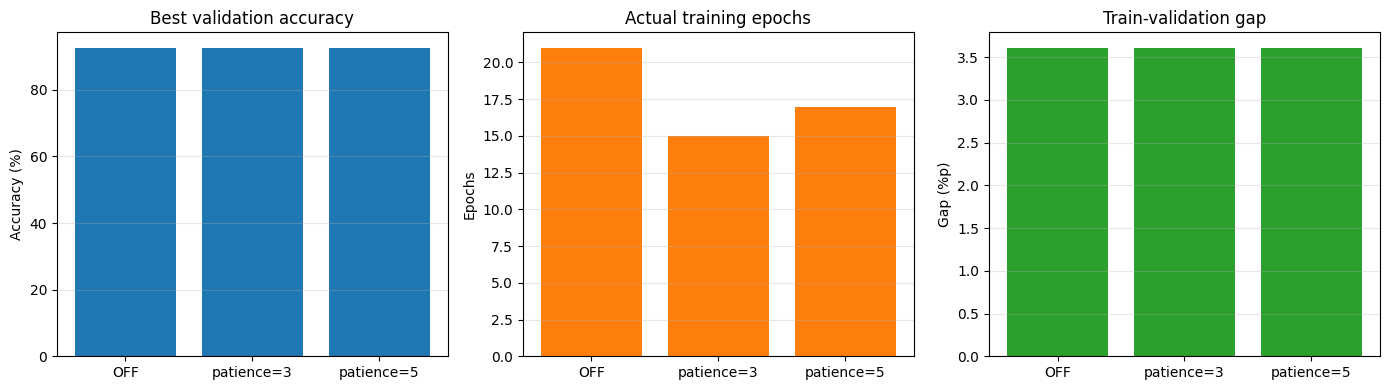

In [34]:
names=[row["setting"] for row in early_stopping_summary]
fig,axes=plt.subplots(1,3,figsize=(14,4))
axes[0].bar(names,[row["accuracy"]*100 for row in early_stopping_summary])
axes[0].set(title="Best validation accuracy",ylabel="Accuracy (%)")
axes[1].bar(names,[row["epochs_ran"] for row in early_stopping_summary],color="tab:orange")
axes[1].set(title="Actual training epochs",ylabel="Epochs")
axes[2].bar(names,[row["gap"] for row in early_stopping_summary],color="tab:green")
axes[2].set(title="Train-validation gap",ylabel="Gap (%p)")
for axis in axes: axis.grid(axis="y",alpha=0.3)
plt.tight_layout(); plt.show()


# 최종 모델 평가

반복 실험에서 선택된 최종 모델을 지금까지 사용하지 않은 test set으로 한 번 평가합니다. 이 결과는 추가 하이퍼파라미터 선택에 사용하지 않습니다.

In [35]:
final_result = selected_early_stopping_result
final_model = final_result["model"]
device = get_device()
_, _, test_loader = make_loaders()
criterion = nn.CrossEntropyLoss()
test_metrics = evaluate(
    final_model, test_loader, criterion, device, return_predictions=True
)

print("[Final configuration]")
print("Epoch limit: 21")
print("Dropout: 0.2")
print("BatchNorm: False")
print("Hidden units: 256")
print(f"Optimizer: {selected_optimizer}")
print(f"Activation: {selected_activation}")
print(f"Early Stopping: {selected_early_stopping}")
print(f"Actual training epochs: {final_result['epochs_ran']}")
print(f"Restored validation-loss epoch: {final_result['best_epoch']}")
print(f"Validation accuracy at restored checkpoint: {final_result['best_valid_accuracy']*100:.2f}%")
print(f"Validation loss at restored checkpoint: {final_result['best_valid_loss']:.4f}")
print(f"Train-validation accuracy gap (eval mode): {final_result['accuracy_gap']:.2f}%p")
print(f"Test accuracy: {test_metrics['accuracy']*100:.2f}%")
print(f"Test loss: {test_metrics['loss']:.4f}")


[Final configuration]
Epoch limit: 21
Dropout: 0.2
BatchNorm: False
Hidden units: 256
Optimizer: Adam
Activation: ReLU
Early Stopping: patience=3
Actual training epochs: 15
Restored validation-loss epoch: 12
Validation accuracy at restored checkpoint: 92.60%
Validation loss at restored checkpoint: 0.2055
Train-validation accuracy gap (eval mode): 3.61%p
Test accuracy: 92.24%
Test loss: 0.2276


## 최종_시각화

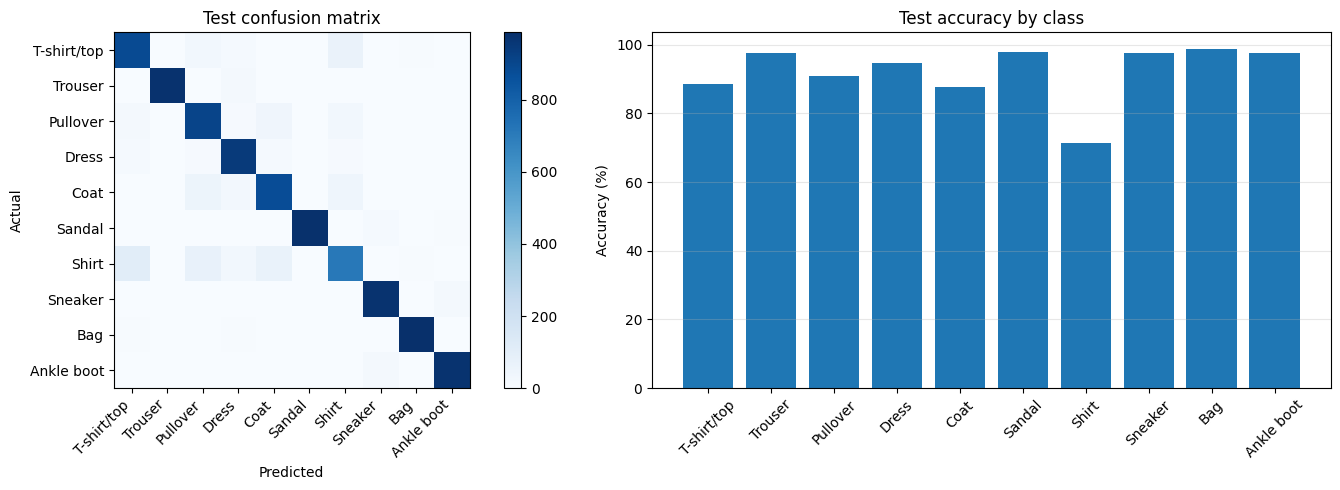

In [36]:
confusion_matrix = torch.zeros(10, 10, dtype=torch.int64)
for target, prediction in zip(test_metrics["targets"], test_metrics["predictions"]):
    confusion_matrix[target, prediction] += 1

per_class_accuracy = (
    confusion_matrix.diag() / confusion_matrix.sum(dim=1).clamp(min=1)
).numpy() * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
image = axes[0].imshow(confusion_matrix.numpy(), cmap="Blues")
axes[0].set(title="Test confusion matrix", xlabel="Predicted", ylabel="Actual")
axes[0].set_xticks(range(10), CLASS_NAMES, rotation=45, ha="right")
axes[0].set_yticks(range(10), CLASS_NAMES)
fig.colorbar(image, ax=axes[0])

axes[1].bar(CLASS_NAMES, per_class_accuracy, color="tab:blue")
axes[1].set(title="Test accuracy by class", ylabel="Accuracy (%)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()
